In [1]:
!pip install qiskit
!pip install qiskit_aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ea8dc5a1d73f00f00e100acf3b47d53a004804ee755707ab1b3e7e2c636089d7
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initial state of qubit 0:


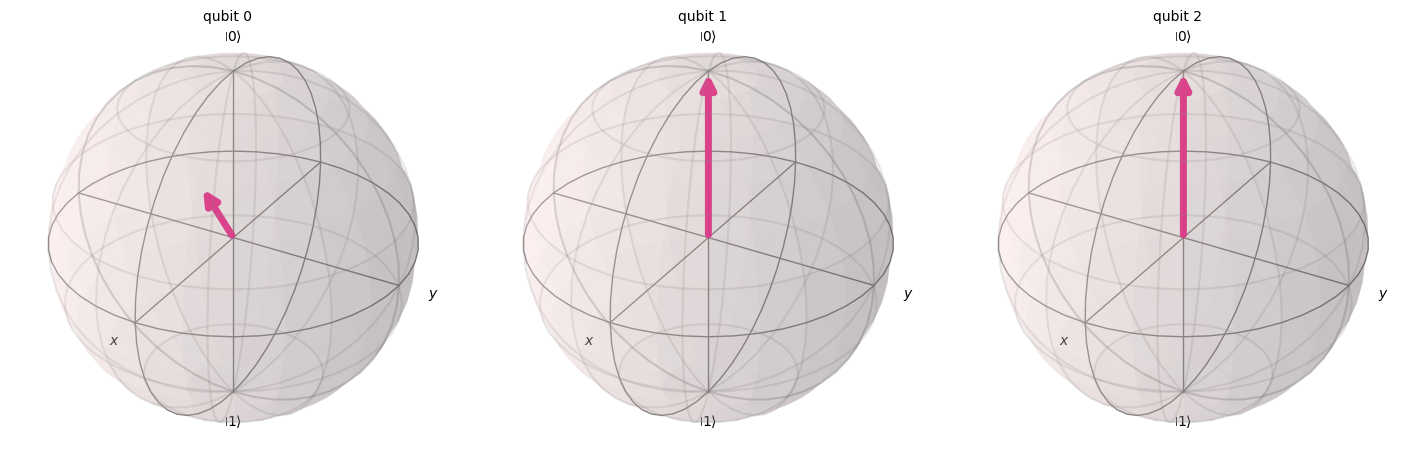

Fidelity between initial and teleported states: 1.000000

Bob’s final qubit (qubit 2) Bloch vector:


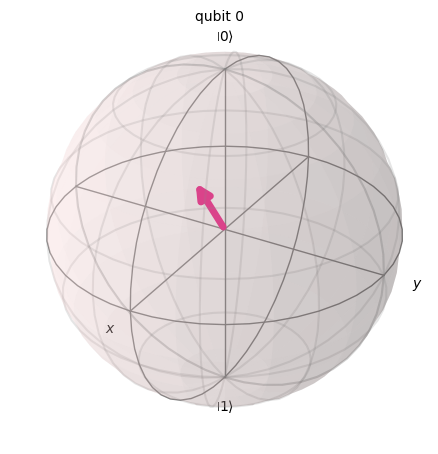

In [2]:
# Quantum Teleportation (Coherent version) – Qiskit 2.x compatible
# Works on modern qiskit-aer simulators

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Build the teleportation circuit
qc = QuantumCircuit(3)

# Prepare arbitrary state |ψ⟩ on qubit 0
theta, phi = 0.8, 0.3
qc.ry(theta, 0)
qc.rz(phi, 0)

# Save initial state for comparison
sv_initial = Statevector.from_instruction(qc)
print("Initial state of qubit 0:")
display(plot_bloch_multivector(sv_initial))

# Create Bell pair between qubits 1 and 2
qc.h(1)
qc.cx(1, 2)

# Bell measurement part (but coherent)
qc.cx(0, 1)
qc.h(0)

# Coherent corrections
qc.cx(1, 2)
qc.cz(0, 2)

# Save final statevector explicitly (Qiskit 2.x requires this)
qc.save_statevector()

# 2️⃣ Simulate
sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled).result()

# Retrieve the saved statevector
sv_final = result.data(0)["statevector"]
sv_final = Statevector(sv_final)

# 3️⃣ Compare: initial vs Bob’s (qubit 2) final state
rho_bob = partial_trace(sv_final, [0, 1])
rho_init = partial_trace(sv_initial, [1, 2])

# Extract the dominant pure states (since both should be pure)
eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
eigvals_i, eigvecs_i = np.linalg.eigh(rho_init.data)
bob_state = eigvecs_b[:, np.argmax(eigvals_b)]
init_state = eigvecs_i[:, np.argmax(eigvals_i)]

# Compute fidelity
fidelity = np.abs(np.vdot(init_state, bob_state)) ** 2
print(f"Fidelity between initial and teleported states: {fidelity:.6f}")

# 4️⃣ Visualize Bloch spheres (fixed)
print("\nBob’s final qubit (qubit 2) Bloch vector:")

# Convert rho_bob (DensityMatrix) → pure statevector (dominant eigenvector)
eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
bob_state = eigvecs_b[:, np.argmax(eigvals_b)]  # dominant eigenvector
bob_sv = Statevector(bob_state)

display(plot_bloch_multivector(bob_sv))

Initial state of qubit 0:


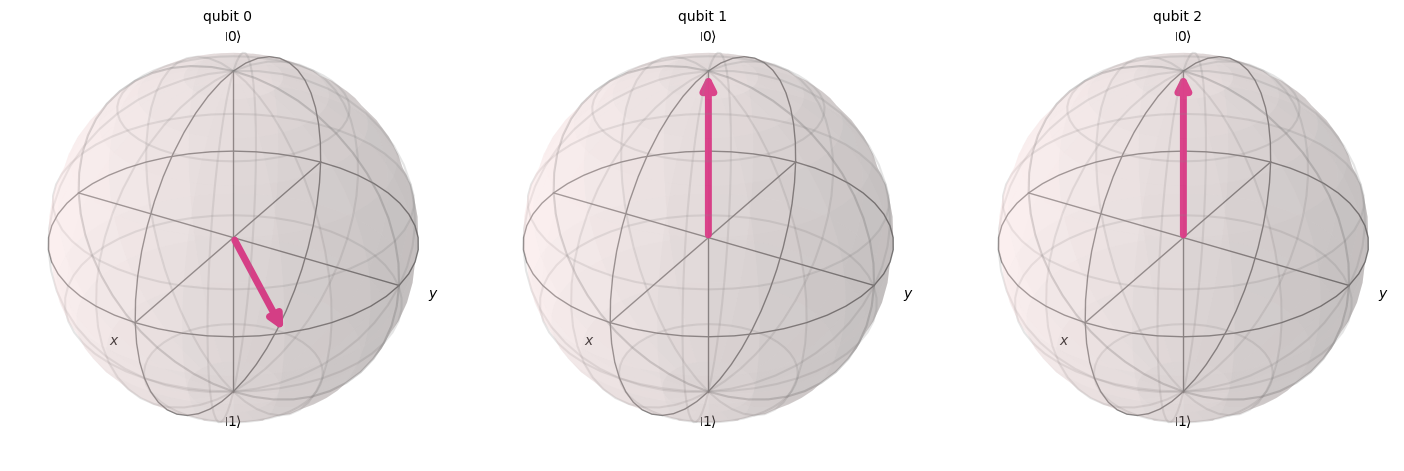

Fidelity between initial and teleported states: 1.000000

Bob’s final qubit (qubit 2) Bloch vector:


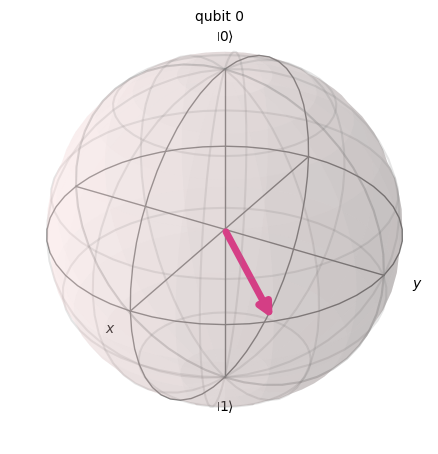

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

qc = QuantumCircuit(3)

theta, phi = np.pi/2, np.pi/4
qc.ry(theta, 0)
qc.rz(phi, 0)

sv_initial = Statevector.from_instruction(qc)
print("Initial state of qubit 0:")
display(plot_bloch_multivector(sv_initial))

qc.h(1)
qc.cx(1, 2)

qc.cx(0, 1)
qc.h(0)

qc.cx(1, 2)
qc.cz(0, 2)

qc.save_statevector()

sim = AerSimulator()
compiled = transpile(qc, sim)
result = sim.run(compiled).result()

sv_final = result.data(0)["statevector"]
sv_final = Statevector(sv_final)

rho_bob = partial_trace(sv_final, [0, 1])
rho_init = partial_trace(sv_initial, [1, 2])

eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
eigvals_i, eigvecs_i = np.linalg.eigh(rho_init.data)
bob_state = eigvecs_b[:, np.argmax(eigvals_b)]
init_state = eigvecs_i[:, np.argmax(eigvals_i)]

fidelity = np.abs(np.vdot(init_state, bob_state)) ** 2
print(f"Fidelity between initial and teleported states: {fidelity:.6f}")

print("\nBob’s final qubit (qubit 2) Bloch vector:")
bob_sv = Statevector(bob_state)
display(plot_bloch_multivector(bob_sv))

Initial state of qubit 0:


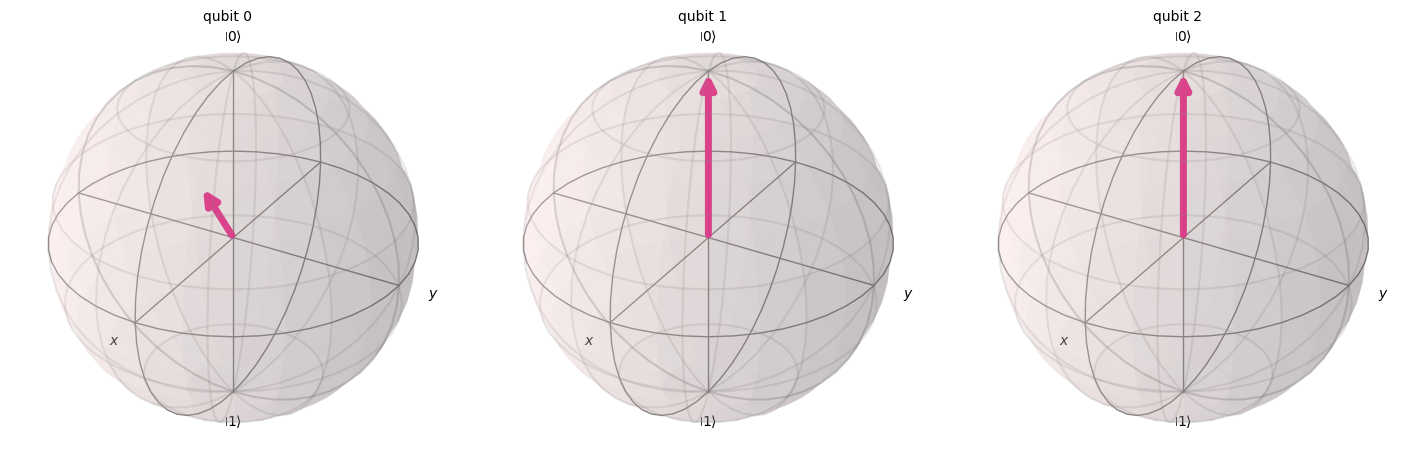

Fidelity between initial and teleported states: 1.000000

Bob’s final qubit (qubit 2) Bloch vector:


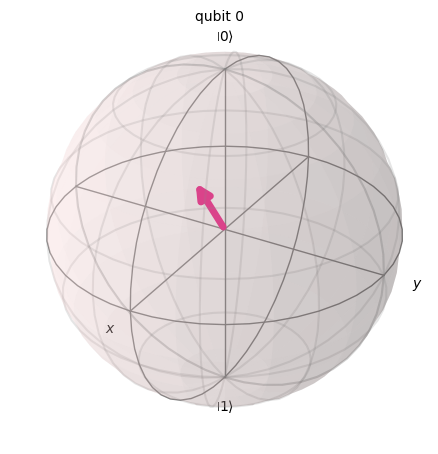

In [6]:
from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

theta, phi = 0.8, 0.3

qc_init = QuantumCircuit(3)
qc_init.ry(theta, 0)
qc_init.rz(phi, 0)
sv_initial = Statevector.from_instruction(qc_init)
print("Initial state of qubit 0:")
display(plot_bloch_multivector(sv_initial))

qc = QuantumCircuit(3, 2)
c0 = ClassicalRegister(1, name="c0")
c1 = ClassicalRegister(1, name="c1")
qc.add_register(c0, c1)

qc.ry(theta, 0)
qc.rz(phi, 0)

qc.barrier()
qc.h(1)
qc.cx(1, 2)

qc.barrier()
qc.cx(0, 1)
qc.h(0)

qc.barrier()
qc.measure(0, c0)
qc.measure(1, c1)

qc.barrier()
with qc.if_test((c1, 1)):
    qc.x(2)
with qc.if_test((c0, 1)):
    qc.z(2)

qc.save_statevector()

sim = AerSimulator(method='statevector')
compiled = transpile(qc, sim)
result = sim.run(compiled).result()

sv_final = result.data(0)["statevector"]
sv_final = Statevector(sv_final)

rho_bob = partial_trace(sv_final, [0, 1])
rho_init = partial_trace(sv_initial, [1, 2])

eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
eigvals_i, eigvecs_i = np.linalg.eigh(rho_init.data)
bob_state = eigvecs_b[:, np.argmax(eigvals_b)]
init_state = eigvecs_i[:, np.argmax(eigvals_i)]

fidelity = np.abs(np.vdot(init_state, bob_state)) ** 2
print(f"Fidelity between initial and teleported states: {fidelity:.6f}")


print("\nBob’s final qubit (qubit 2) Bloch vector:")
bob_sv = Statevector(bob_state)
display(plot_bloch_multivector(bob_sv))

Running 20 random state teleportations...
Average Fidelity: 1.000000


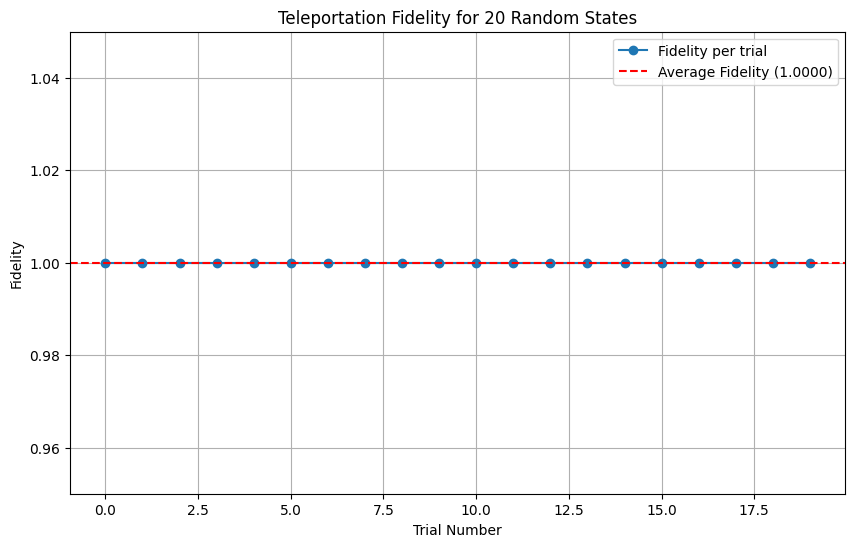

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

def run_teleportation_fidelity(theta, phi, sim):
    qc = QuantumCircuit(3)

    qc_init = QuantumCircuit(3)
    qc_init.ry(theta, 0)
    qc_init.rz(phi, 0)
    sv_initial = Statevector.from_instruction(qc_init)

    qc.ry(theta, 0)
    qc.rz(phi, 0)
    qc.h(1)
    qc.cx(1, 2)
    qc.cx(0, 1)
    qc.h(0)
    qc.cx(1, 2)
    qc.cz(0, 2)
    qc.save_statevector()

    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    sv_final = Statevector(result.data(0)["statevector"])

    rho_bob = partial_trace(sv_final, [0, 1])
    rho_init = partial_trace(sv_initial, [1, 2])

    eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
    eigvals_i, eigvecs_i = np.linalg.eigh(rho_init.data)
    bob_state = eigvecs_b[:, np.argmax(eigvals_b)]
    init_state = eigvecs_i[:, np.argmax(eigvals_i)]

    fidelity = np.abs(np.vdot(init_state, bob_state)) ** 2
    return fidelity

sim = AerSimulator()
num_samples = 20
fidelities = []

print(f"Running {num_samples} random state teleportations...")

for i in range(num_samples):
    rand_theta = np.random.rand() * np.pi
    rand_phi = np.random.rand() * 2 * np.pi
    f = run_teleportation_fidelity(rand_theta, rand_phi, sim)
    fidelities.append(f)

average_fidelity = np.mean(fidelities)
print(f"Average Fidelity: {average_fidelity:.6f}")

plt.figure(figsize=(10, 6))
plt.plot(fidelities, 'o-', label='Fidelity per trial')
plt.axhline(average_fidelity, color='r', linestyle='--', label=f'Average Fidelity ({average_fidelity:.4f})')
plt.xlabel("Trial Number")
plt.ylabel("Fidelity")
plt.title("Teleportation Fidelity for 20 Random States")
plt.ylim(0.95, 1.05)
plt.legend()
plt.grid(True)
plt.show()

Step 1: Initial State


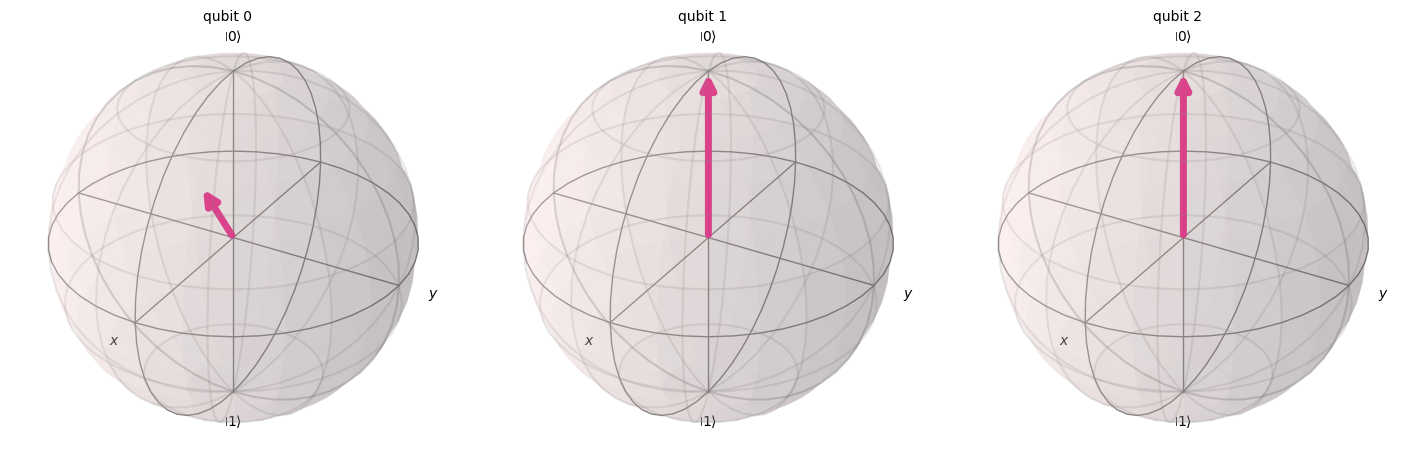

Step 2: Bell Pair Created (q1, q2)


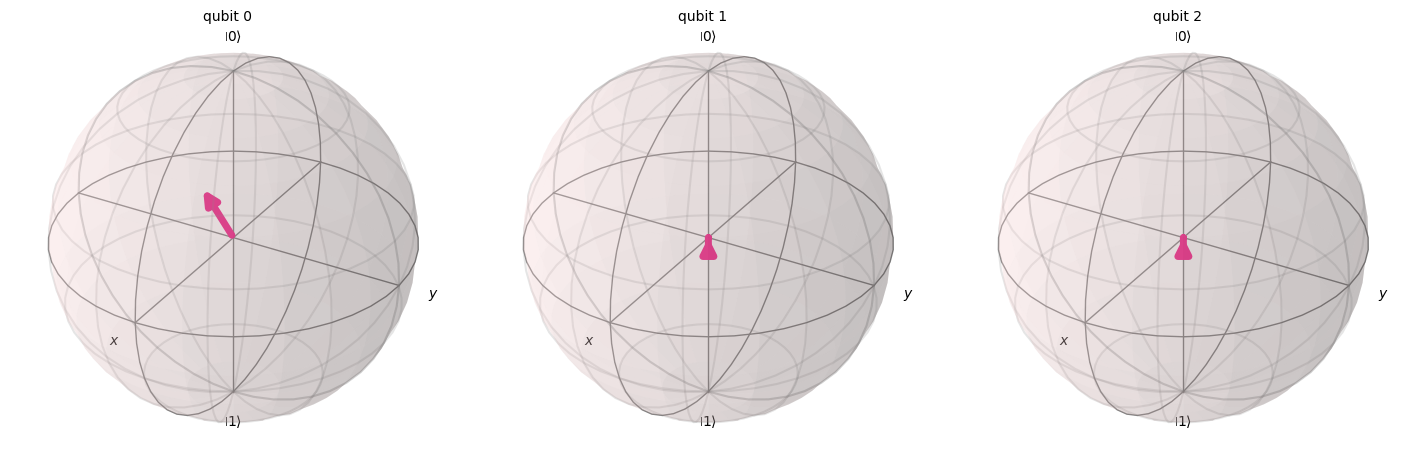

Step 3: CNOT (q0 -> q1)


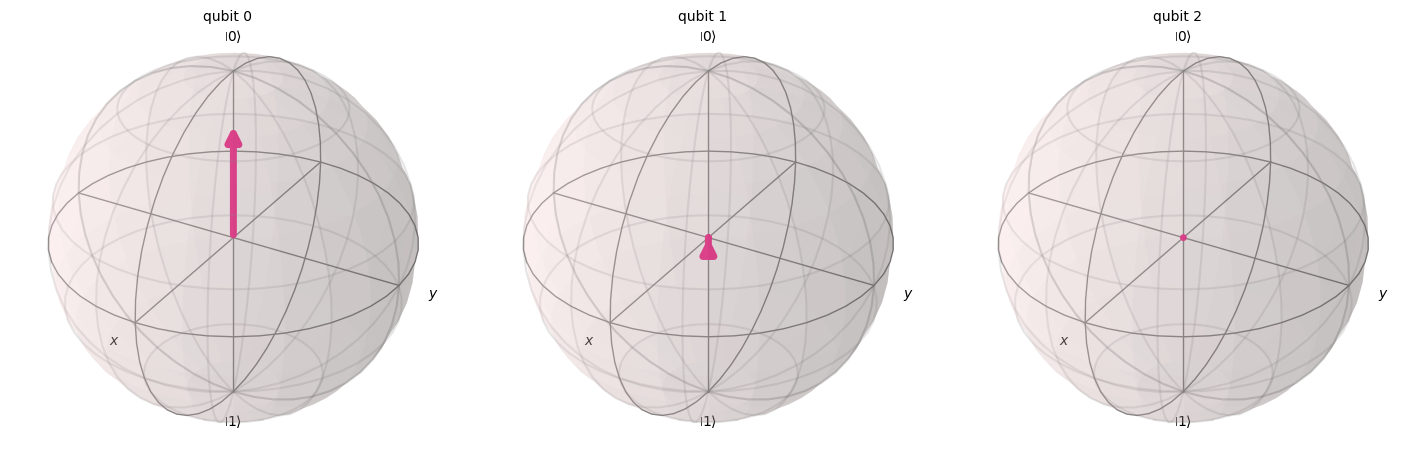

Step 4: Hadamard (q0)


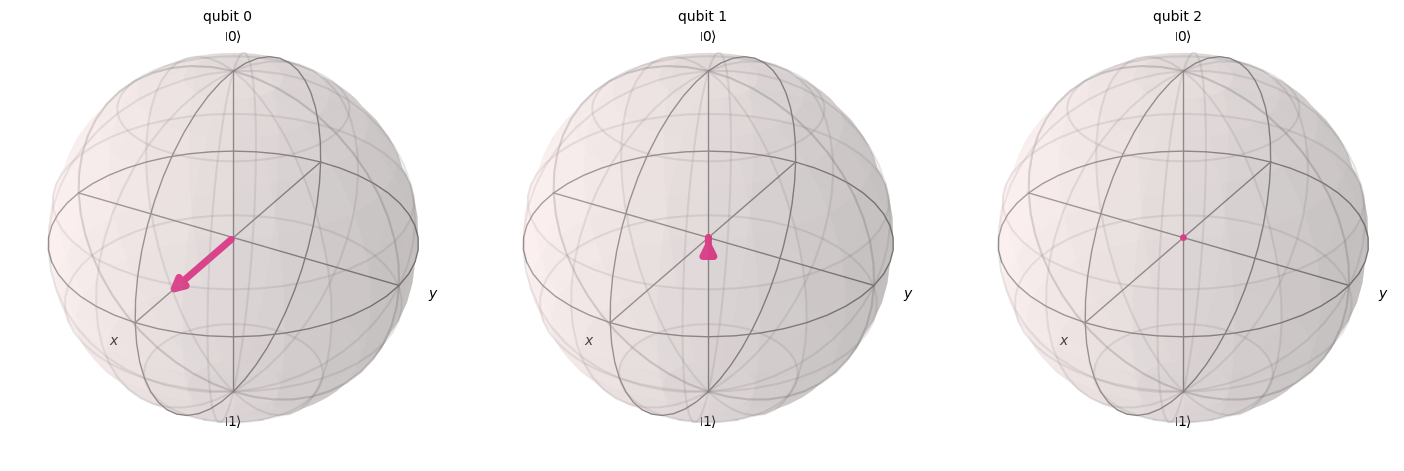

Step 5: CNOT (q1 -> q2) - Correction 1


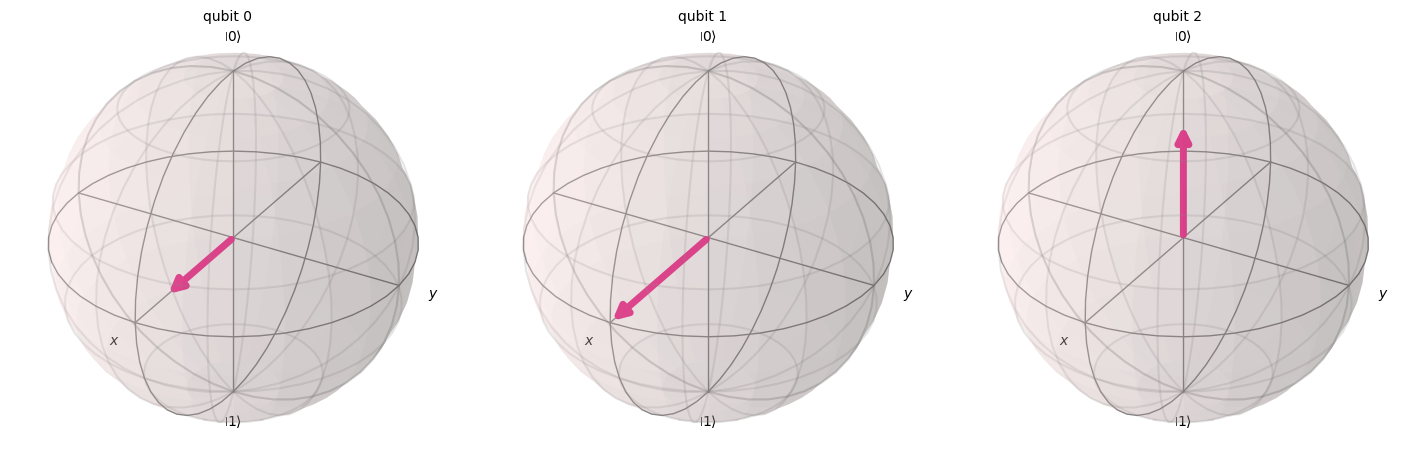

Step 6: CZ (q0 -> q2) - Correction 2 (Final State)


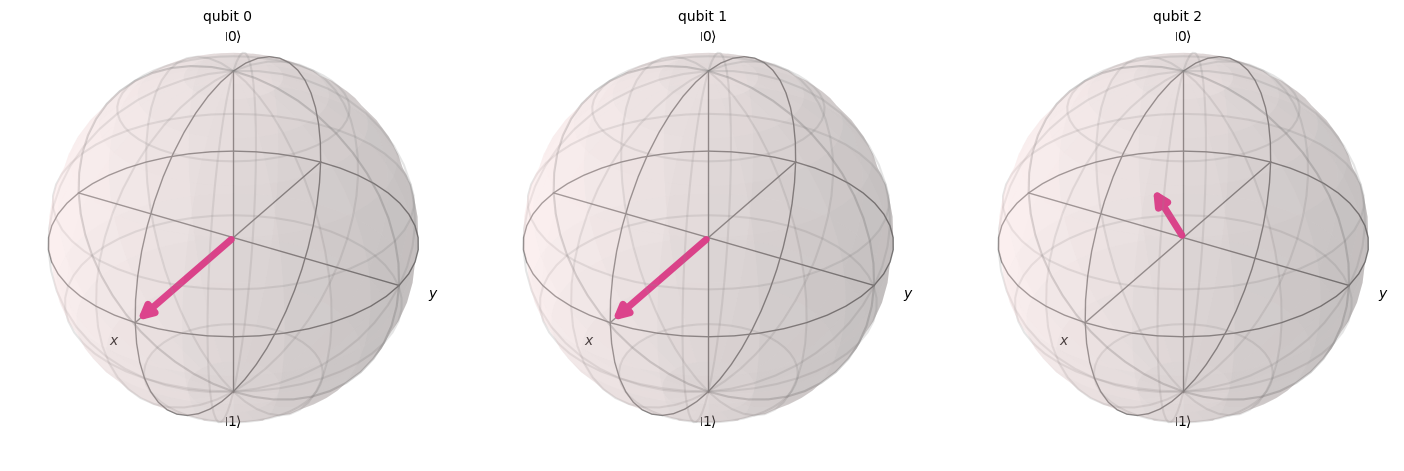

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt

qc = QuantumCircuit(3)

theta, phi = 0.8, 0.3
qc.ry(theta, 0)
qc.rz(phi, 0)
qc.save_statevector(label='s1_initial_state')

qc.h(1)
qc.cx(1, 2)
qc.save_statevector(label='s2_bell_pair')

qc.cx(0, 1)
qc.save_statevector(label='s3_cnot_01')

qc.h(0)
qc.save_statevector(label='s4_h_0')

qc.cx(1, 2)
qc.save_statevector(label='s5_cnot_12')

qc.cz(0, 2)
qc.save_statevector(label='s6_final')

sim = AerSimulator(method='statevector')
compiled = transpile(qc, sim)
result = sim.run(compiled).result()
data = result.data(0)

print("Step 1: Initial State")
display(plot_bloch_multivector(data['s1_initial_state']))
plt.show()

print("Step 2: Bell Pair Created (q1, q2)")
display(plot_bloch_multivector(data['s2_bell_pair']))
plt.show()

print("Step 3: CNOT (q0 -> q1)")
display(plot_bloch_multivector(data['s3_cnot_01']))
plt.show()

print("Step 4: Hadamard (q0)")
display(plot_bloch_multivector(data['s4_h_0']))
plt.show()

print("Step 5: CNOT (q1 -> q2) - Correction 1")
display(plot_bloch_multivector(data['s5_cnot_12']))
plt.show()

print("Step 6: CZ (q0 -> q2) - Correction 2 (Final State)")
display(plot_bloch_multivector(data['s6_final']))
plt.show()

Initial state of qubit 0:


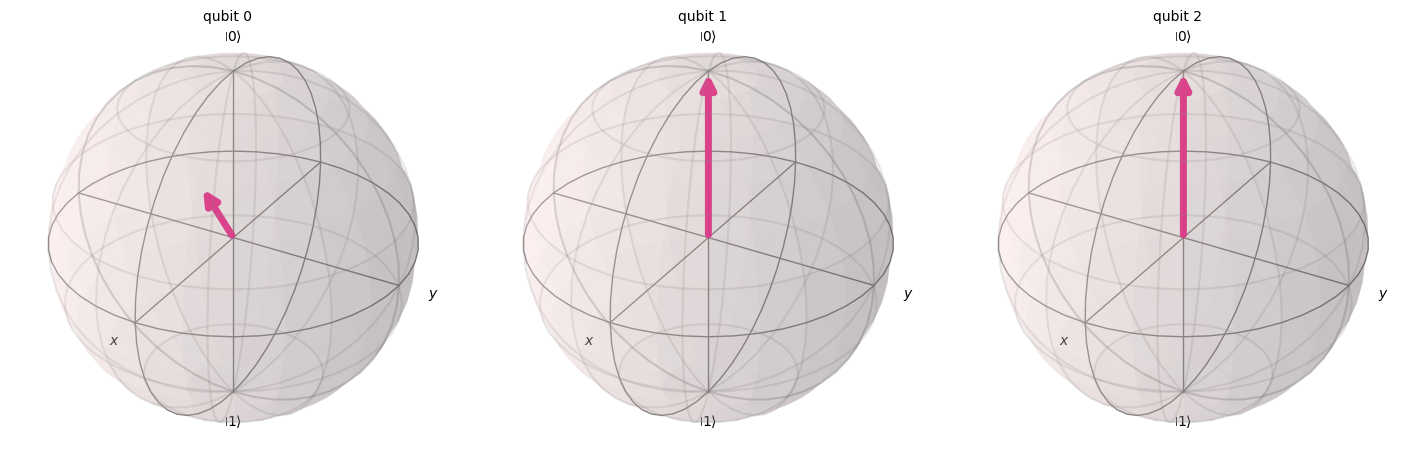

Fidelity with noise: 1.000000

Bob’s final qubit (qubit 2) Bloch vector (with noise):


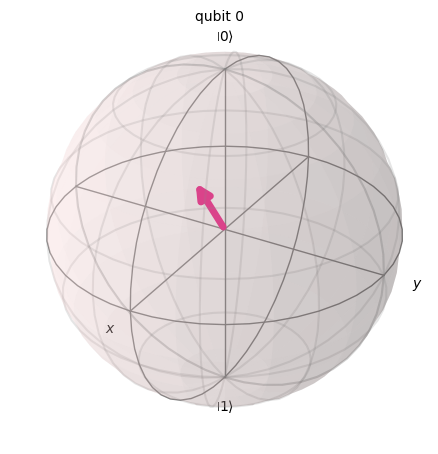

In [9]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, partial_trace
from qiskit.visualization import plot_bloch_multivector
import numpy as np
import matplotlib.pyplot as plt
from qiskit_aer.noise import NoiseModel, depolarizing_error

depol_error_1q = depolarizing_error(0.01, 1)
depol_error_2q = depolarizing_error(0.05, 2)

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depol_error_1q, ['ry', 'rz', 'h'])
noise_model.add_all_qubit_quantum_error(depol_error_2q, ['cx', 'cz'])

sim_noise = AerSimulator(noise_model=noise_model)

qc = QuantumCircuit(3)

theta, phi = 0.8, 0.3
qc.ry(theta, 0)
qc.rz(phi, 0)

sv_initial = Statevector.from_instruction(qc)
print("Initial state of qubit 0:")
display(plot_bloch_multivector(sv_initial))

qc.h(1)
qc.cx(1, 2)

qc.cx(0, 1)
qc.h(0)

qc.cx(1, 2)
qc.cz(0, 2)

qc.save_statevector()

compiled = transpile(qc, sim_noise)
result = sim_noise.run(compiled).result()

sv_final = result.data(0)["statevector"]
sv_final = Statevector(sv_final)

rho_bob = partial_trace(sv_final, [0, 1])
rho_init = partial_trace(sv_initial, [1, 2])

eigvals_b, eigvecs_b = np.linalg.eigh(rho_bob.data)
eigvals_i, eigvecs_i = np.linalg.eigh(rho_init.data)
bob_state = eigvecs_b[:, np.argmax(eigvals_b)]
init_state = eigvecs_i[:, np.argmax(eigvals_i)]

fidelity = np.abs(np.vdot(init_state, bob_state)) ** 2
print(f"Fidelity with noise: {fidelity:.6f}")

print("\nBob’s final qubit (qubit 2) Bloch vector (with noise):")
bob_sv = Statevector(bob_state)
display(plot_bloch_multivector(bob_sv))